# GeoBrain Geomodel Simulation

Geological Property Field Generation using FFT-MA.

Features demonstrated:
1. Single field simulation (FFT-MA)
2. Porosity field with physical bounds
3. Multiple realizations for uncertainty quantification
4. 3D field with isotropic correlation
5. Correlation model comparison (spherical / exponential / gaussian)

---

**FFT-MA** (Fast Fourier Transform – Moving Average) generates spatially
correlated Gaussian random fields via frequency-domain convolution.
Compared with Sequential Gaussian Simulation (SGS), FFT-MA has lower
computational cost and is well suited for large 3-D grids.

This notebook walks through five progressively richer examples.

In [1]:
import sys
import os
sys.path.insert(0, '../..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from geobrain.geomodel import Simulator, SimulationConfig
from geobrain.vis import plot_field, plot_comparison

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [2]:
import matplotlib
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

## Example 1 — Single Gaussian Field

Generate one standard-normal random field with anisotropic spatial
correlation.

| Parameter | Meaning |
|-----------|---------|
| `shape` | Grid dimensions $(n_x, n_y, n_z)$ |
| `lh` / `lv` | Horizontal / vertical correlation length — larger values produce smoother fields |
| `mean`, `std` | Target first- and second-order statistics |
| `seed` | Random seed for reproducibility |

Generated field shape: torch.Size([64, 64, 64])
Field statistics: mean=-0.0149, std=1.0635
Value range: [-4.1067, 4.5026]


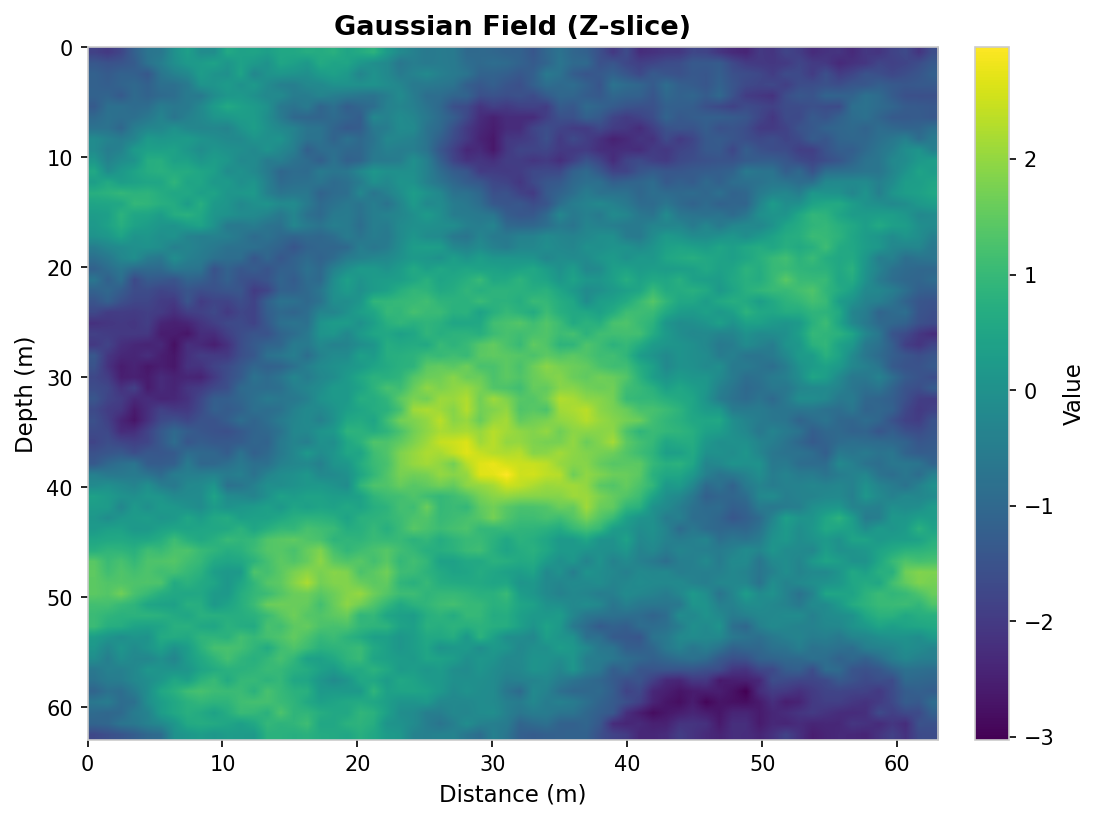

In [3]:
config = SimulationConfig(
    shape=(64, 64, 64),   # Grid dimensions (nx, ny, nz)
    lh=20.0,              # Horizontal correlation length
    lv=5.0,               # Vertical correlation length
    mean=0.0,             # Mean value
    std=1.0,              # Standard deviation
    seed=42,              # For reproducibility
    device=device,
)

simulator = Simulator.create('fft_ma')
field1 = simulator.simulate(config)

print(f"Generated field shape: {field1.shape}")
print(f"Field statistics: mean={field1.mean():.4f}, std={field1.std():.4f}")
print(f"Value range: [{field1.min():.4f}, {field1.max():.4f}]")

fig, ax = plot_field(field1[:, :, 32], label='Value')
ax.set_title('Gaussian Field (Z-slice)')
plt.savefig(os.path.join(FIGS_DIR, '01_gaussian_field.png'))
plt.show()

## Example 2 — Bounded Porosity Field

Geological properties like porosity must lie within physically meaningful
bounds (e.g. 0.05–0.35).  A **sigmoid transform** maps the unbounded
Gaussian field into $[\phi_{\min},\,\phi_{\max}]$:

$$\phi = \phi_{\min} + (\phi_{\max} - \phi_{\min})\,\sigma(x)$$

A longer horizontal correlation (`lh = 25`) mimics lateral continuity,
while a shorter vertical correlation (`lv = 8`) creates layered heterogeneity.

Porosity field shape: torch.Size([64, 64, 64])
Porosity statistics: mean=0.1923, std=0.0676
Value range: [0.0541, 0.3463]


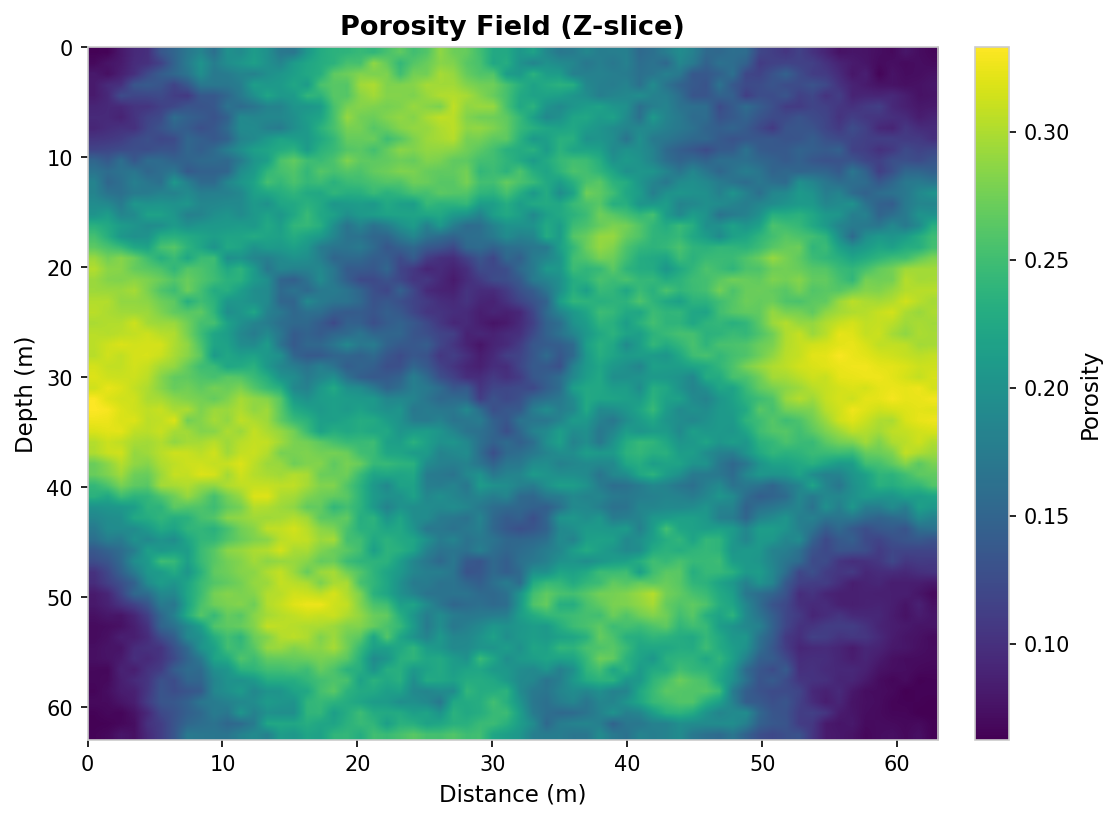

In [4]:
# Physical parameters for porosity
phi_min, phi_max = 0.05, 0.35

def sigmoid_transform(x, vmin=phi_min, vmax=phi_max):
    """Transform standard normal to bounded range via sigmoid."""
    return vmin + (vmax - vmin) * torch.sigmoid(x)

config = SimulationConfig(
    shape=(64, 64, 64),
    lh=25.0,   # Longer horizontal correlation for porosity
    lv=8.0,    # Shorter vertical (layering effect)
    mean=0.0,  # Generate standard normal first
    std=1.0,
    seed=123,
    device=device,
)

simulator = Simulator.create('fft_ma', transform=sigmoid_transform)
porosity = simulator.simulate(config)

print(f"Porosity field shape: {porosity.shape}")
print(f"Porosity statistics: mean={porosity.mean():.4f}, std={porosity.std():.4f}")
print(f"Value range: [{porosity.min():.4f}, {porosity.max():.4f}]")

fig, ax = plot_field(porosity[:, :, 32], label='Porosity')
ax.set_title('Porosity Field (Z-slice)')
plt.savefig(os.path.join(FIGS_DIR, '01_porosity_field.png'))
plt.show()

## Example 3 — Multiple Realizations for Uncertainty Quantification

In uncertainty quantification (UQ) we generate many *equiprobable
realizations* that share the same statistical model.  Setting
`n_realizations = 10` produces ten independent fields in one call.

We then compute ensemble statistics — **mean**, **standard deviation**,
and **P10 / P90 percentiles** — to characterize predictive uncertainty.

Generated 10 realizations
Output shape: torch.Size([10, 64, 64, 64])
Statistics across realizations:
  Mean of means: 0.1994
  Mean of stds: 0.0488
  P10-P90 range: [0.1465, 0.2523]


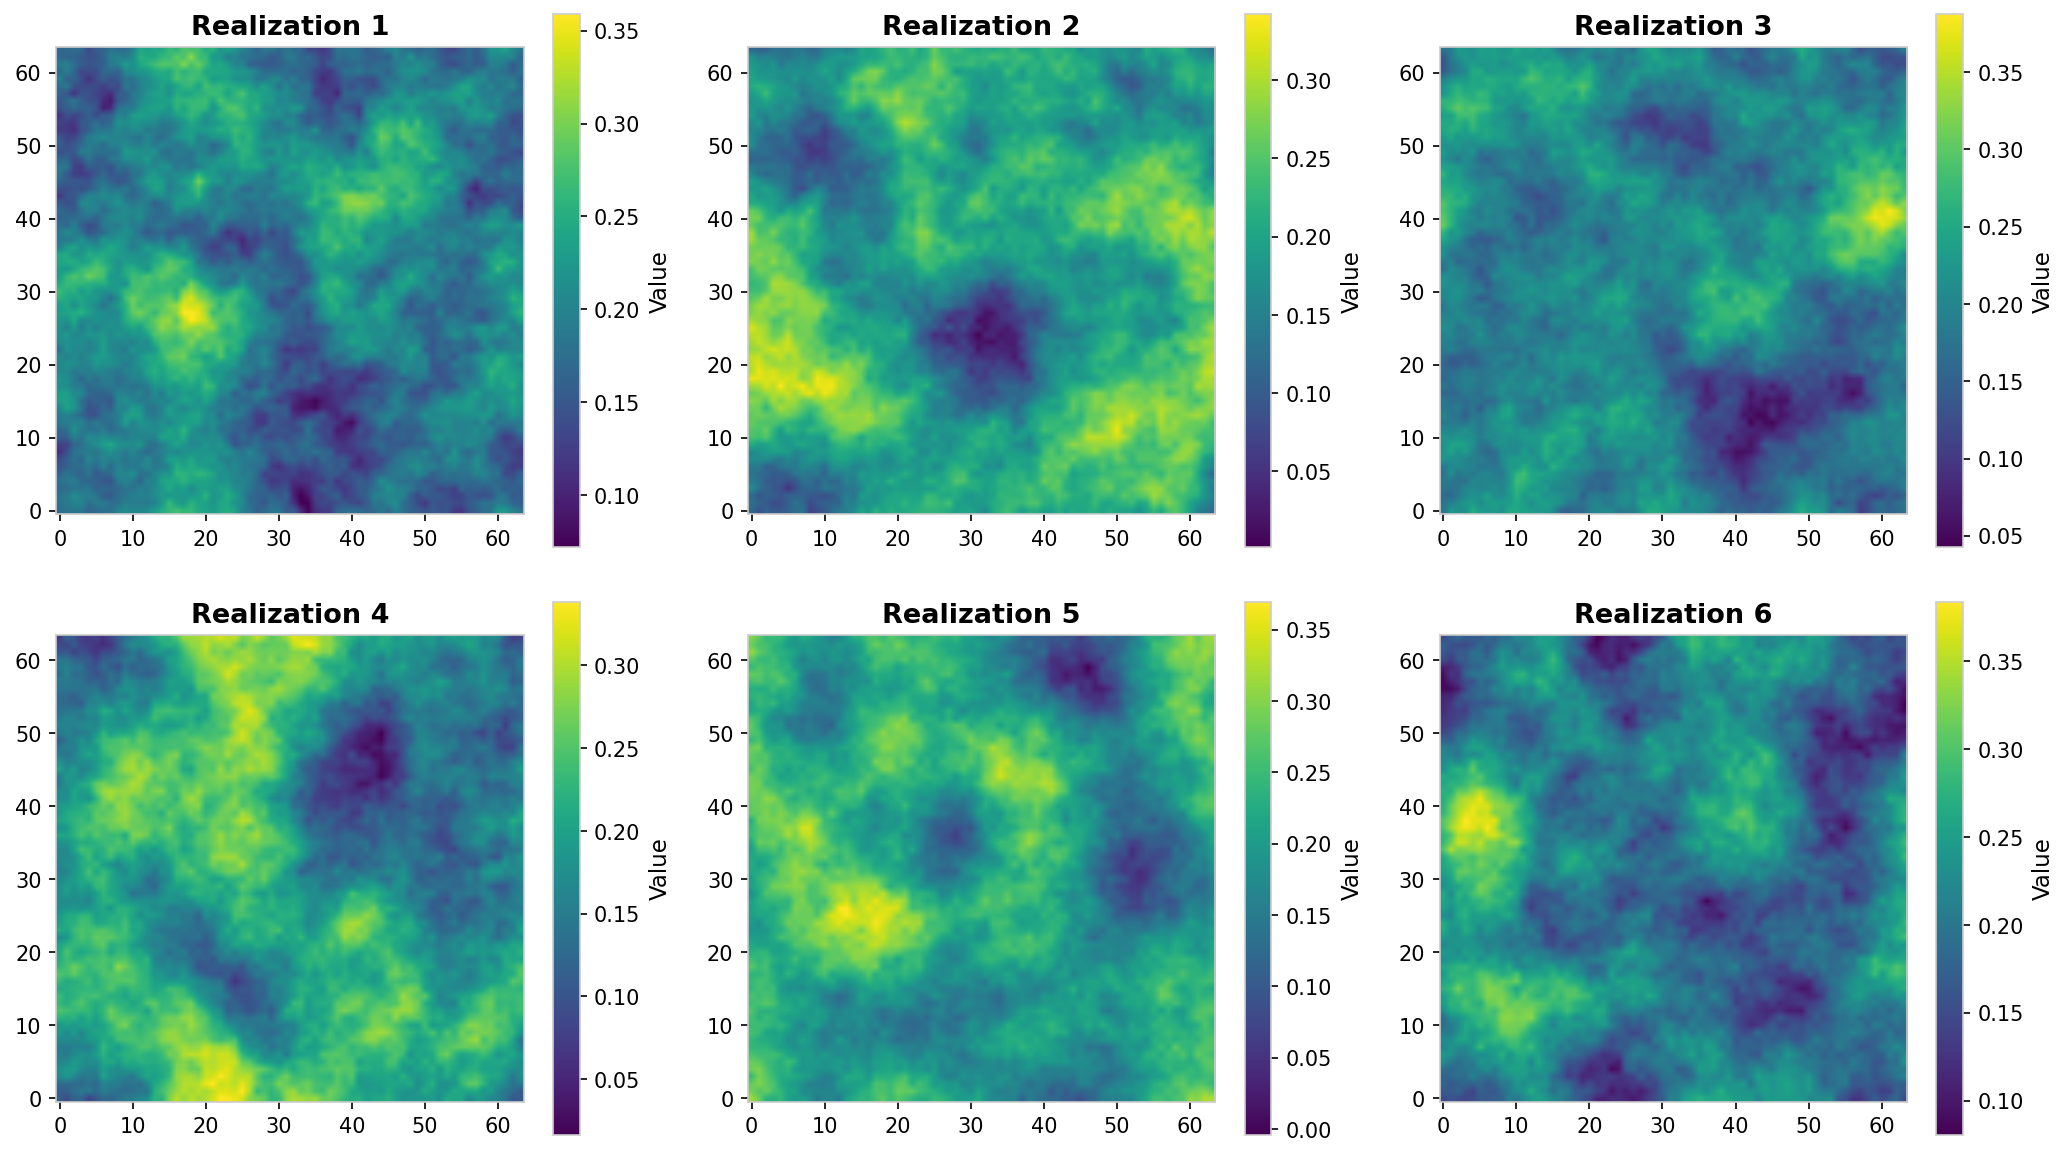

In [5]:
n_realizations = 10

config = SimulationConfig(
    shape=(64, 64, 64),
    lh=10.0,
    lv=3.0,
    mean=0.20,
    std=0.05,
    n_realizations=n_realizations,
    seed=789,
    device=device,
)

simulator = Simulator.create('fft_ma')
realizations = simulator.simulate(config)

print(f"Generated {n_realizations} realizations")
print(f"Output shape: {realizations.shape}")

# Compute statistics across realizations
mean_field = realizations.mean(dim=0)
std_field = realizations.std(dim=0)
p10 = torch.quantile(realizations, 0.1, dim=0)
p90 = torch.quantile(realizations, 0.9, dim=0)

print(f"Statistics across realizations:")
print(f"  Mean of means: {mean_field.mean():.4f}")
print(f"  Mean of stds: {std_field.mean():.4f}")
print(f"  P10-P90 range: [{p10.mean():.4f}, {p90.mean():.4f}]")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

slice_idx = 32

for i in range(6):
    ax = axes[i // 3, i % 3]
    im = ax.imshow(realizations[i, :, :, slice_idx].cpu().numpy().T, origin='lower',
                   cmap='viridis', interpolation='bilinear')
    ax.set_title(f'Realization {i+1}')
    plt.colorbar(im, ax=ax, label='Value')

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '01_realizations.png'))
plt.show()

## Example 4 — Isotropic 3-D Field

When horizontal and vertical correlation lengths are equal (`lh == lv`),
the resulting field is **isotropic** — spatial correlation is identical
in every direction.  This is appropriate for modelling homogeneous media.

Isotropic 3D field shape: torch.Size([64, 64, 64])
Statistics: mean=-0.1379, std=0.9871


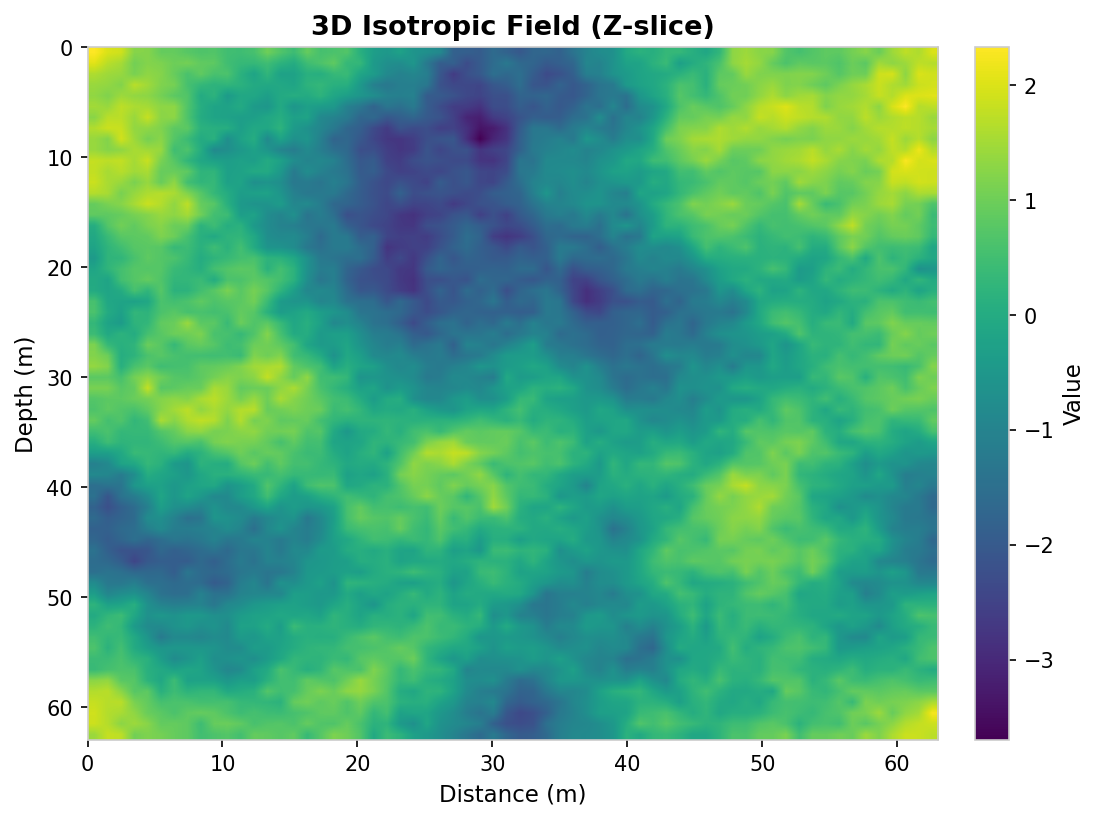

In [6]:
config = SimulationConfig(
    shape=(64, 64, 64),  # 3D cubic grid
    lh=15.0,             # Horizontal correlation length
    lv=15.0,             # Same as lh for isotropic
    mean=0.0,
    std=1.0,
    seed=2024,
    device=device,
)

simulator = Simulator.create('fft_ma')
field_iso = simulator.simulate(config)

print(f"Isotropic 3D field shape: {field_iso.shape}")
print(f"Statistics: mean={field_iso.mean():.4f}, std={field_iso.std():.4f}")

fig, ax = plot_field(field_iso[:, :, 32], label='Value')
ax.set_title('3D Isotropic Field (Z-slice)')
plt.savefig(os.path.join(FIGS_DIR, '01_isotropic_field.png'))
plt.show()

## Example 5 — Correlation Model Comparison

Different variogram / correlation functions control the field *texture*:

| Model | Characteristics |
|-------|----------------|
| **Spherical** | Finite range — variables become uncorrelated beyond the range |
| **Exponential** | Slower decay, no strict range |
| **Gaussian** | Smoothest; best for highly continuous fields |

All three use the same random seed so differences are due solely to the
correlation function.


--- Correlation Model Comparison ---
  spherical: mean=0.0592, std=1.0906
  exponential: mean=0.0546, std=1.0509
  gaussian: mean=0.0742, std=1.1291


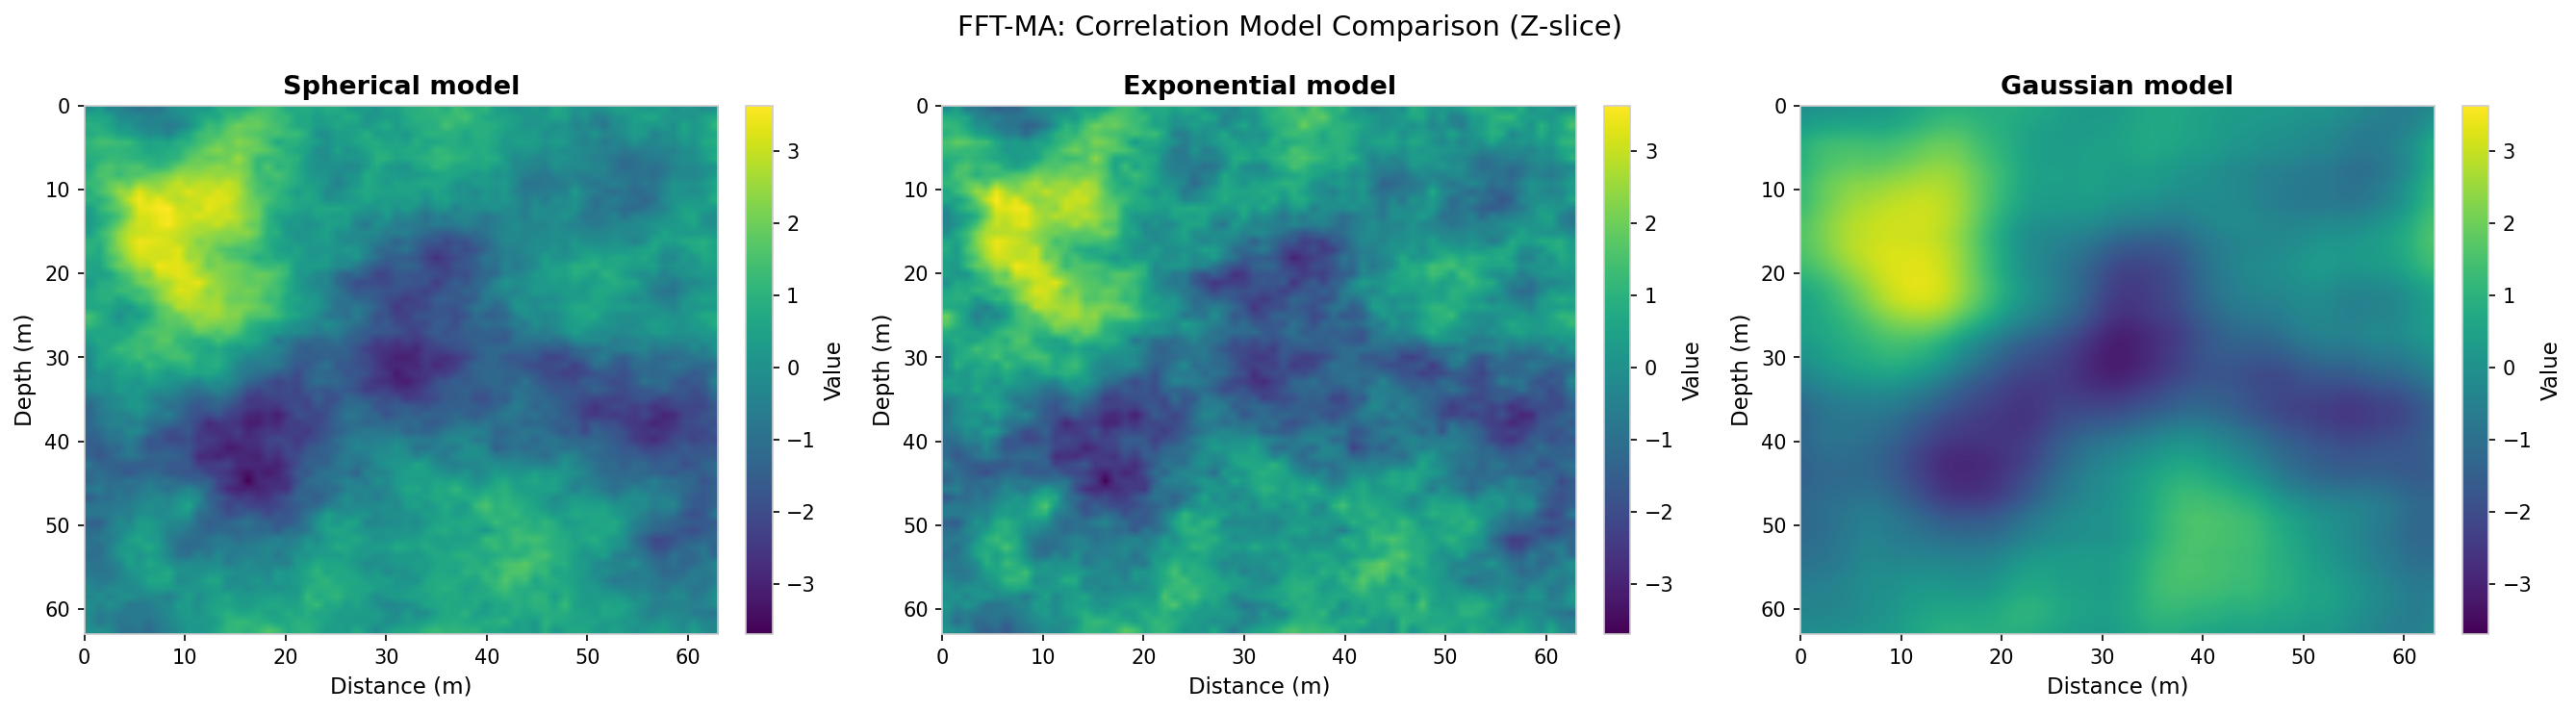

In [7]:
print("\n--- Correlation Model Comparison ---")

config_corr = SimulationConfig(
    shape=(64, 64, 64),
    lh=15.0,
    lv=8.0,
    seed=100,
    device=device,
)

models = ['spherical', 'exponential', 'gaussian']
slice_idx = 32  # Middle Z-slice

corr_fields = []
corr_titles = []
for model in models:
    sim = Simulator.create('fft_ma', correlation_model=model)
    field = sim.simulate(config_corr)
    corr_fields.append(field[:, :, slice_idx].T)
    corr_titles.append(f'{model.capitalize()} model')
    print(f"  {model}: mean={field.mean():.4f}, std={field.std():.4f}")

fig, axes = plot_comparison(
    corr_fields, titles=corr_titles,
    cmap='viridis', label='Value',
    figsize=(18, 5),
)
fig.suptitle('FFT-MA: Correlation Model Comparison (Z-slice)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '01_correlation_comparison.png'))
plt.show()